## m

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

plt.rcParams["font.sans-serif"]=['KaiTi']
plt.rcParams["axes.unicode_minus"]=False

In [31]:
# 读数据
x=np.linspace(-np.pi,np.pi,300).reshape(-1,1)
y=np.sin(x)+np.random.uniform(-0.5,0.5,300).reshape(-1,1)

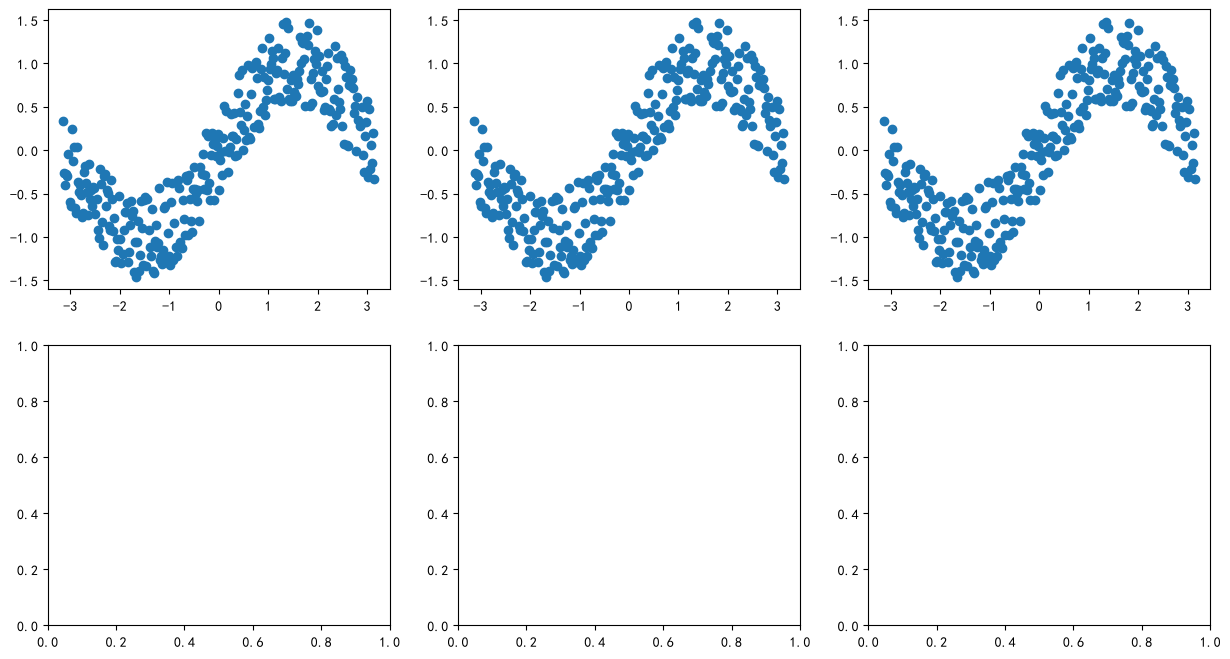

In [32]:
#  散点图
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs[0, 0].scatter(x, y)
axs[0, 1].scatter(x, y)
axs[0, 2].scatter(x, y)

In [33]:
# 划分数据集
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,random_state=42)
print(x.shape,y.shape)
print(train_x.shape,test_x.shape)
print(train_y.shape,test_y.shape)

(300, 1) (300, 1)
(240, 1) (60, 1)
(240, 1) (60, 1)


In [34]:
# 定义模型
model = LinearRegression()
poly20=PolynomialFeatures(degree=20)# 构建多项式
train_x1=poly20.fit_transform(train_x)
test_x1=poly20.transform(test_x)
print(train_x1.shape,test_x1.shape)

(240, 21) (60, 21)


In [37]:
# 训练模型
model.fit(train_x1,train_y)
print(model.coef_,model.intercept_)# 查看参数

[[ 0.00000000e+00  7.68648256e-01 -4.80108662e-01  7.81121126e-01
   1.66479899e+00 -8.56668018e-01 -2.39415616e+00  1.81811799e-01
   1.73569155e+00  1.06162376e-01 -7.07260066e-01 -6.83703795e-02
   1.72231823e-01  1.62712511e-02 -2.56056402e-02 -1.97269352e-03
   2.27795596e-03  1.21327083e-04 -1.11409040e-04 -3.00657194e-06
   2.30398373e-06]] [-0.02680458]


In [43]:
# 模型评估
test_loss=mean_absolute_error(test_y,model.predict(test_x1))
train_loss=mean_absolute_error(train_y,model.predict(train_x1))
print(f"过拟合时的测试误差：{test_loss}")
print(f"过拟合时的训练误差：{train_loss}")

过拟合时的测试误差：0.2758733376850701
过拟合时的训练误差：0.23974610707296948


In [47]:
# 绘制曲线
axs[0,0].plot(x,model.predict(poly20.transform(x)),c='r')
axs[0,0].text(-3,1,f"测试集均方误差:{test_loss:.4f}")
axs[1,0].bar(np.arange(len(model.coef_.reshape(-1))),model.coef_.reshape(-1))

<BarContainer object of 21 artists>

In [53]:
# 加上L1 Lasso回归
model=Lasso(alpha=0.009,max_iter=10000)
model.fit(train_x1,train_y)
print(model.coef_,model.intercept_)# 查看参数
test_loss=mean_absolute_error(test_y,model.predict(test_x1))
train_loss=mean_absolute_error(train_y,model.predict(train_x1))
print(f"过拟合时的测试误差：{test_loss}")
print(f"过拟合时的训练误差：{train_loss}")
# 绘制曲线
axs[0,1].plot(x,model.predict(poly20.transform(x)),c='r')
axs[0,1].text(-3,1,f"测试集均方误差:{test_loss:.4f}")
axs[1,1].bar(np.arange(len(model.coef_.reshape(-1))),model.coef_.reshape(-1))

[ 0.00000000e+00  8.47830881e-01  0.00000000e+00 -0.00000000e+00
  8.14286599e-04 -3.79329186e-02  5.65423346e-04  2.96989525e-03
 -1.17797032e-05  1.44677374e-04 -1.32508208e-06 -2.79974042e-06
 -4.00621666e-07 -6.93976891e-07 -7.13249038e-08 -5.11714862e-08
 -4.64904427e-09 -1.58963925e-09  1.90982765e-10  1.27159180e-10
  1.00629435e-10] [-0.05324128]
过拟合时的测试误差：0.2694690001812182
过拟合时的训练误差：0.2529240305448161


C:\Users\23716\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.240e+01, tolerance: 1.405e-02
  model = cd_fast.enet_coordinate_descent(


<BarContainer object of 21 artists>

In [58]:
# 加上L2 Ridge回归
model=Ridge(alpha=0.009,max_iter=9990000)
model.fit(train_x1,train_y)
print(model.coef_,model.intercept_)# 查看参数
test_loss=mean_absolute_error(test_y,model.predict(test_x1))
train_loss=mean_absolute_error(train_y,model.predict(train_x1))
print(f"过拟合时的测试误差：{test_loss}")
print(f"过拟合时的训练误差：{train_loss}")
# 绘制曲线
axs[0,2].plot(x,model.predict(poly20.transform(x)),c='r')
axs[0,2].text(-3,1,f"测试集均方误差:{test_loss:.4f}")
axs[1,2].bar(np.arange(len(model.coef_.reshape(-1))),model.coef_.reshape(-1))

[ 0.00000000e+00  1.24704785e+00  1.34938230e-01 -5.90023035e-01
 -1.69394348e-01  1.14434610e-01 -1.70943390e-01  1.67830918e-01
  2.80210148e-01 -1.34988529e-01 -1.50361980e-01  4.39284881e-02
  4.31402593e-02 -7.68081193e-03 -7.32139755e-03  7.56652472e-04
  7.36147697e-04 -3.96475802e-05 -4.05019835e-05  8.61415902e-07
  9.38234402e-07] [0.02333733]
过拟合时的测试误差：0.28181585955662647
过拟合时的训练误差：0.2319282163282562


C:\Users\23716\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.64281e-23): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


<BarContainer object of 21 artists>

# 合并

(300, 1) (300, 1)
(240, 1) (60, 1)
(240, 1) (60, 1)
(240, 21) (60, 21)
[[ 0.00000000e+00  1.38134027e+00  2.91502626e-01 -2.11041123e+00
  -1.33838191e+00  3.16076787e+00  1.92851045e+00 -2.39193525e+00
  -1.32504112e+00  1.00554057e+00  5.13043426e-01 -2.53183774e-01
  -1.20478867e-01  3.91450545e-02  1.75505941e-02 -3.64201082e-03
  -1.55180750e-03  1.87076155e-04  7.63181244e-05 -4.07415705e-06
  -1.60165883e-06]] [0.00303204]
过拟合时的测试误差：0.26698923157626436
过拟合时的训练误差：0.24662245571316813


C:\Users\23716\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.450e+01, tolerance: 1.376e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\23716\.conda\envs\ml_env\Lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=3.46815e-23): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


[ 0.00000000e+00  7.93624622e-01  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -0.00000000e+00  0.00000000e+00 -1.98939433e-02
 -6.69414837e-04  4.48461873e-03  2.72862270e-04  5.14697703e-05
  2.12940172e-05 -8.46103170e-05 -1.34512881e-05  2.65357210e-06
  4.92555734e-07  7.10069685e-07  1.33203627e-07 -4.38503149e-08
 -9.00982056e-09] [0.00621321]
过拟合时的测试误差：0.269867492347124
过拟合时的训练误差：0.2579724247168668
[ 0.00000000e+00  1.15686396e+00 -6.61105385e-02 -8.91974744e-01
 -2.09765291e-01  1.13714795e+00  5.19152923e-01 -8.28879532e-01
 -4.19518853e-01  3.42324967e-01  1.76063612e-01 -8.62927318e-02
 -4.36955296e-02  1.35877496e-02  6.67706130e-03 -1.30428598e-03
 -6.18374092e-04  6.96917141e-05  3.18501475e-05 -1.58521617e-06
 -6.99705561e-07] [0.02133324]
过拟合时的测试误差：0.26348308087014033
过拟合时的训练误差：0.2485840342471387


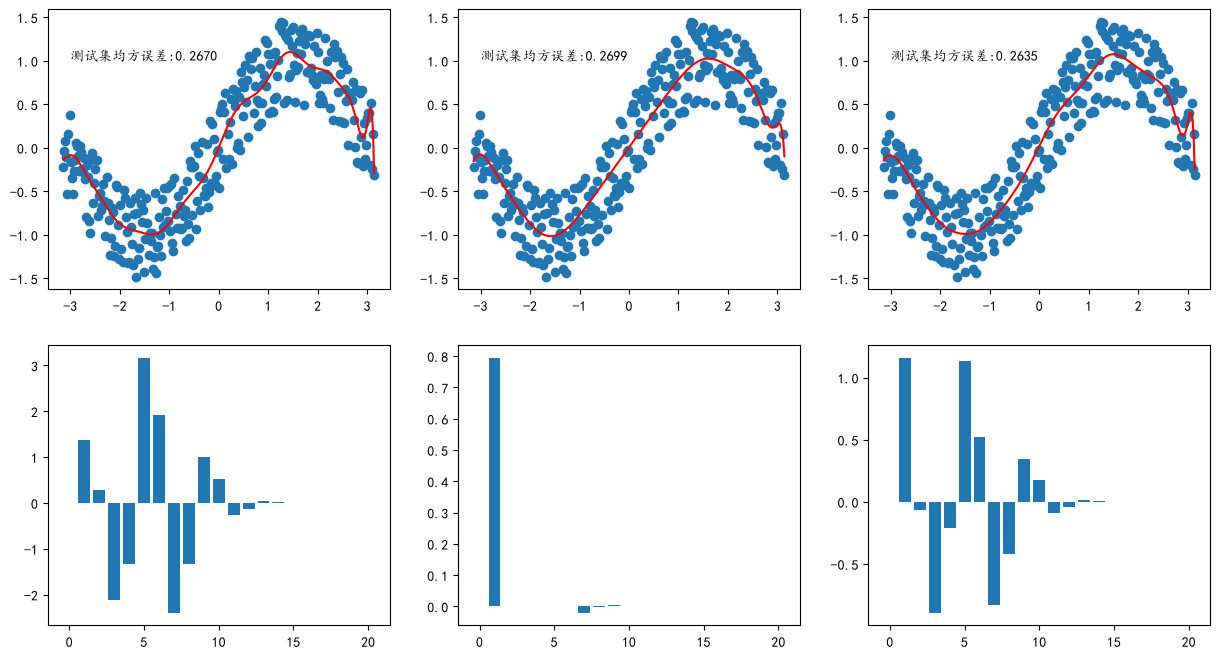

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

plt.rcParams["font.sans-serif"]=['KaiTi']
plt.rcParams["axes.unicode_minus"]=False

# 读数据：生成sin(x)叠加噪声的样本
x=np.linspace(-np.pi,np.pi,300).reshape(-1,1)
y=np.sin(x)+np.random.uniform(-0.5,0.5,300).reshape(-1,1)

# 创建画布：2行3列子图，第一行画拟合曲线，第二行画权重柱状图
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs[0, 0].scatter(x, y)
axs[0, 1].scatter(x, y)
axs[0, 2].scatter(x, y)

# 划分数据集：训练集80%，测试集20%
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,random_state=42)
print(x.shape,y.shape)
print(train_x.shape,test_x.shape)
print(train_y.shape,test_y.shape)

# 特征工程：20次多项式特征扩展
model = LinearRegression()
poly20=PolynomialFeatures(degree=20)# 构建多项式
train_x1=poly20.fit_transform(train_x)
test_x1=poly20.transform(test_x)
print(train_x1.shape,test_x1.shape)

# 【1】普通线性回归（无正则，会过拟合）
model.fit(train_x1,train_y)
print(model.coef_,model.intercept_)# 查看参数

# 模型评估：平均绝对误差MAE
test_loss=mean_absolute_error(test_y,model.predict(test_x1))
train_loss=mean_absolute_error(train_y,model.predict(train_x1))
print(f"过拟合时的测试误差：{test_loss}")
print(f"过拟合时的训练误差：{train_loss}")

# 绘制拟合曲线 + 权重柱状图
axs[0,0].plot(x,model.predict(poly20.transform(x)),c='r')
axs[0,0].text(-3,1,f"测试集均方误差:{test_loss:.4f}")
axs[1,0].bar(np.arange(len(model.coef_.reshape(-1))),model.coef_.reshape(-1))

# 【2】加上L1 Lasso回归
model=Lasso(alpha=0.019,max_iter=9990000)
model.fit(train_x1,train_y)
print(model.coef_,model.intercept_)# 查看参数

# 模型评估
test_loss=mean_absolute_error(test_y,model.predict(test_x1))
train_loss=mean_absolute_error(train_y,model.predict(train_x1))
print(f"过拟合时的测试误差：{test_loss}")
print(f"过拟合时的训练误差：{train_loss}")

# 绘制拟合曲线 + 权重柱状图
axs[0,1].plot(x,model.predict(poly20.transform(x)),c='r')
axs[0,1].text(-3,1,f"测试集均方误差:{test_loss:.4f}")
axs[1,1].bar(np.arange(len(model.coef_.reshape(-1))),model.coef_.reshape(-1))

# 【3】加上L2 Ridge回归
model=Ridge(alpha=0.019,max_iter=9990000)
model.fit(train_x1,train_y)
print(model.coef_,model.intercept_)# 查看参数

# 模型评估
test_loss=mean_absolute_error(test_y,model.predict(test_x1))
train_loss=mean_absolute_error(train_y,model.predict(train_x1))
print(f"过拟合时的测试误差：{test_loss}")
print(f"过拟合时的训练误差：{train_loss}")

# 绘制拟合曲线 + 权重柱状图
axs[0,2].plot(x,model.predict(poly20.transform(x)),c='r')
axs[0,2].text(-3,1,f"测试集均方误差:{test_loss:.4f}")
axs[1,2].bar(np.arange(len(model.coef_.reshape(-1))),model.coef_.reshape(-1))

plt.show()